In [ ]:
#É possível prever se um passageiro do RMS Titanic sobreviveria ao naufrágio usando seus dados?

#Importando as bibliotecas.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#Importando o dataframe
df = pd.read_csv('train.csv')
#Mostrando as 5 primeiras linhas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
#Analisando o dataframe.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
#Identificando os problemas do dataframe.
#isnull para chamar os dados incompletos.
#sum para somar os dados incompletos e mostrar a quantidade total.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
#Fazer a limpeza dos dados.
#Trocar os valores nulos da coluna 'Age' para a média de idade
df['Age'] = df['Age'].fillna(df['Age'].mean())

#Excluir a coluna 'Cabin'
df = df.drop('Cabin', axis=1)

#Excluir os faltantes da coluna 'Embarked'
df = df.dropna(subset=['Embarked'])   

In [16]:
#Converter strings em numeros.
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

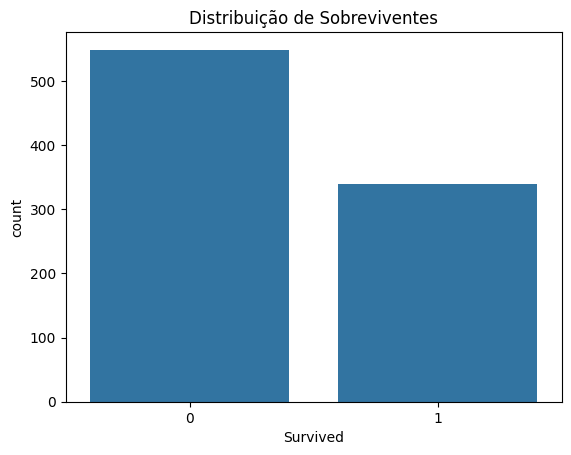

In [17]:
#Ver quantas pessoas sobreviveram
sns.countplot(
    x='Survived', 
    data=df
)
plt.title('Distribuição de Sobreviventes')
plt.show()
#A maioria dos passageiros não sobreviveu ao naufrágio, indicando um dataset desbalanceado com mais casos de morte do que sobrevivência.

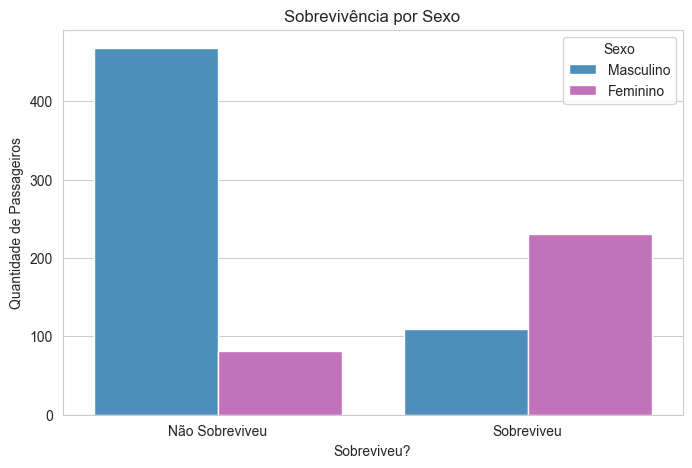

In [32]:
#Tamanho do gráfico
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
#Criando o gráfico
sns.countplot(
    x='Survived', 
    hue='Sex', 
    data=df, 
    palette=["#3c92cc", "#cf63c6"]
)
#Título do gráfico
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sobreviveu?')
plt.ylabel('Quantidade de Passageiros')
#Alterando ticks
plt.xticks(
    ticks=[0,1],
    labels=['Não Sobreviveu', 'Sobreviveu']
)
#Alterando a legenda
plt.legend(
    title='Sexo', 
    labels=['Masculino', 'Feminino']
)
plt.show()

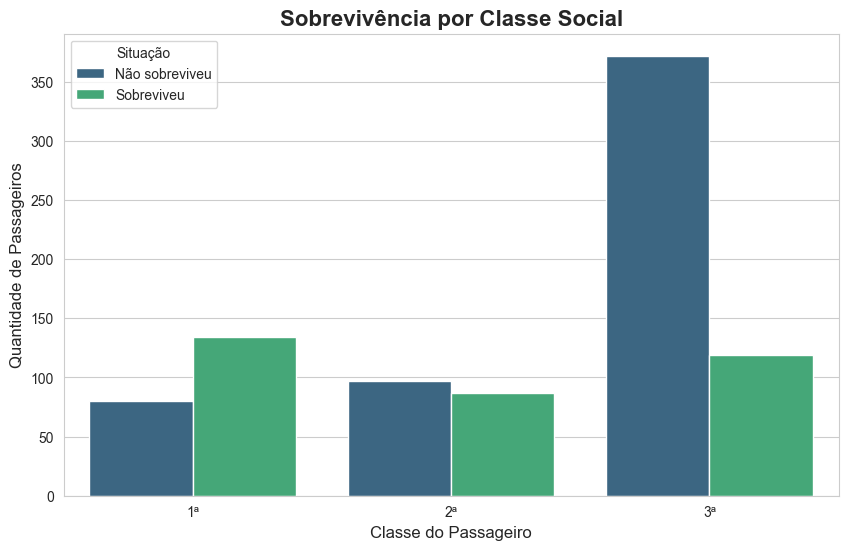

In [38]:
#A classe social influenciou quem sobreviveu no RMS Titanic?
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.countplot(
    x='Pclass', 
    hue='Survived', 
    data=df,
    palette='viridis'
)
plt.title(
    'Sobrevivência por Classe Social',
    fontsize=16,
    fontweight='bold'
)
plt.legend(
    labels=['Não sobreviveu', 'Sobreviveu'],
    title='Situação'
)
plt.ylabel('Quantidade de Passageiros', fontsize=12)
plt.xlabel('Classe do Passageiro', fontsize=12)
plt.xticks(
    ticks=[0,1,2],
    labels=['1ª', '2ª', '3ª']
)
plt.show()






Passageiros da 1ª classe tiveram uma taxa de sobrevivência significativamente maior. Já a 3ª classe apresentou o maior número de mortes, sugerindo que fatores socioeconômicos e localização no navio influenciaram a chance de sobrevivência no naufrágio do RMS Titanic.